In [1]:
import jax.scipy as jsp
from scipy.datasets import ascent
import matplotlib as mpl
import jax.numpy as np
import matplotlib.pyplot as plt
import jax
import dLux.utils as dlu
from skimage import data


jax.config.update("jax_enable_x64", True)

2025-04-07 10:08:46.051516: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.85. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


# Defining functions

The Larkin rotation is built from three shears.

In [2]:
def x_shear(array, scale, u, Y):
    """
    Perform a shear transformation in the x-direction on a 2D array.
    The shear is applied in the Fourier domain.
    Parameters:
    - array: 2D numpy array to be sheared.
    - scale: Shear factor.
    """
    F = np.fft.fft(array)

    # perform shear
    F_sheared = F * (np.exp(-2j * np.pi * scale * u * Y))

    # inverse transform and take real part
    return np.fft.ifft(F_sheared).real


def larkin_rotate(array, angle):
    """
    Perform a rotation of the image in the Fourier domain.
    The rotation is applied in the Fourier domain.
    Parameters:
    - array: 2D numpy array to be rotated.
    - angle: Angle of rotation in radians.
    """

    # factors
    a = np.tan(-angle / 2)
    b = -np.sin(-angle)

    # Get the shape of the image
    nx, ny = array.shape

    # setting up coordinates stuff
    u = np.fft.fftfreq(nx)  # frequency coordinates
    y = dlu.nd_coords(ny, 1.0)
    _, Y = np.meshgrid(y, y)

    # sequence of shears
    gx = x_shear(array, a, u, Y)
    gyx = x_shear(gx.T, b, u, Y).T
    gxyx = x_shear(gyx, a, u, Y)

    return gxyx


def larkin_color_rotate(image, angle):
    """
    Rotate a color image in the Fourier domain.
    The rotation is vectorized over the color channels.
    Parameters:
    - image: 3D numpy array (height x width x channels).
    - angle: Angle of rotation in radians.
    """
    return jax.vmap(larkin_rotate, in_axes=(2, None), out_axes=2)(image, angle)

Applying to an image

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.130951122384226..1.1391221328415497].


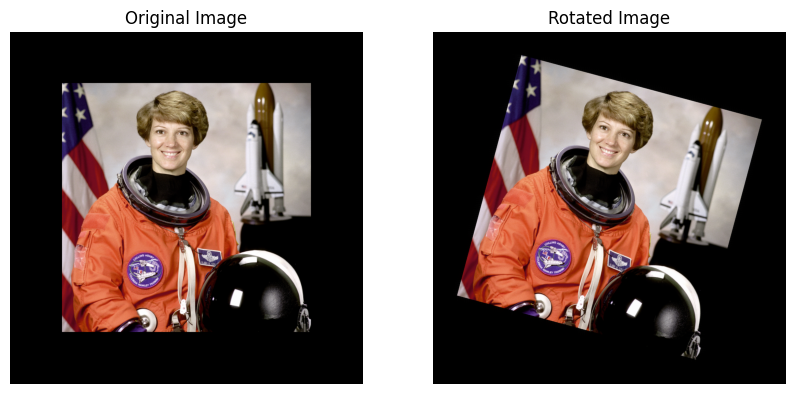

In [3]:
# loading image
image = np.array(data.astronaut() / 255.0)  # normalizing to [0, 1]
# padding with zeros so it can fully rotate
pad = int(image.shape[0] * (np.sqrt(2) - 1) // 2 + 1)
image = np.pad(image, ((pad, pad), (pad, pad), (0, 0)))

# rotating image
angle = np.pi / 12
rotated_image = larkin_color_rotate(image, angle)

# plotting

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(rotated_image)
plt.title("Rotated Image")
plt.axis("off")
plt.show()

Let's try on mono

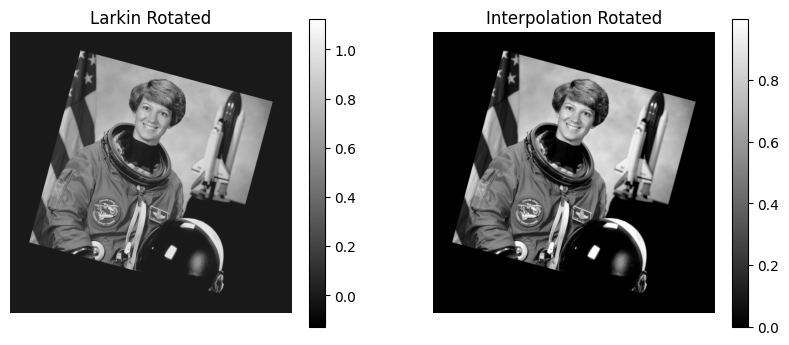

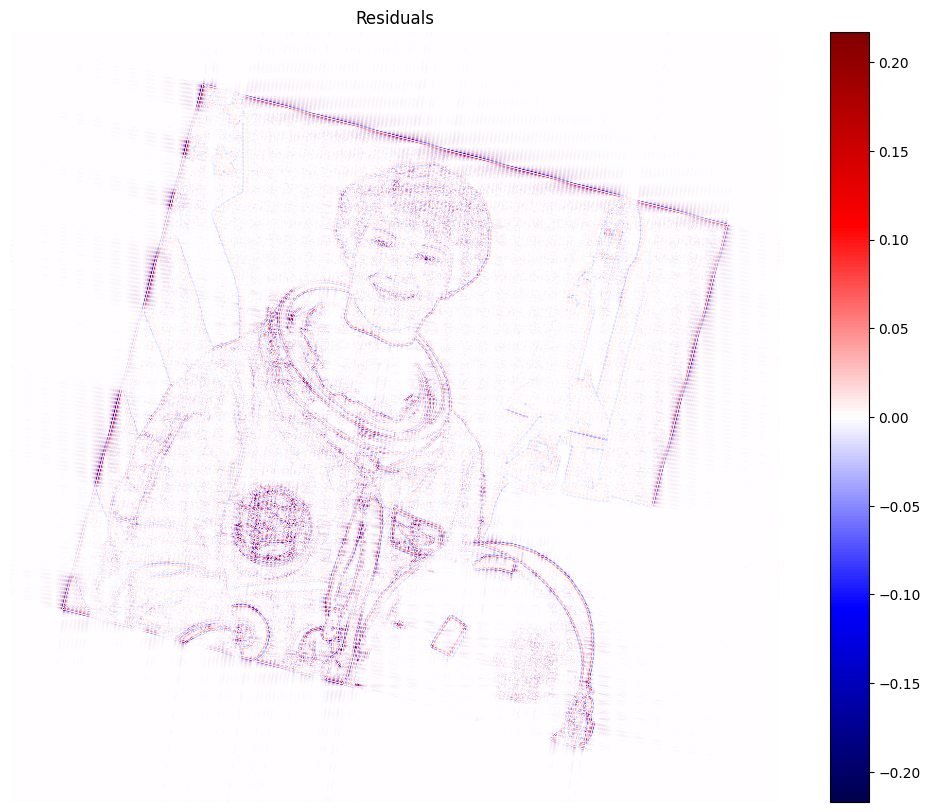

In [4]:
mono_image = np.cbrt(
    np.prod(image, axis=2)
)  # Convert to grayscale by combining RGB channels

# rotating image
angle = np.pi / 12
rotated_image = larkin_rotate(mono_image, angle)

# looking at the difference with rotation by interpolation
rotated_interp = dlu.rotate(mono_image, angle)
residuals = rotated_image - rotated_interp

# plotting
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(rotated_image, cmap="grey")
plt.title("Larkin Rotated")
plt.axis("off")
plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(rotated_interp, cmap="grey")
plt.title("Interpolation Rotated")
plt.axis("off")
plt.colorbar()
plt.show()

plt.figure(figsize=(13, 10))
plt.imshow(residuals, cmap="seismic", norm=mpl.colors.CenteredNorm())
plt.title("Residuals")
plt.axis("off")
plt.colorbar()
plt.show()

# Benchmarking

Interpolation

In [5]:
# Compiling
interp_rotate = jax.jit(lambda x, angle: dlu.rotate(x, angle))
interp_rotate(mono_image, angle).block_until_ready()  # warm up

%timeit interp_rotate(mono_image, angle).block_until_ready()

174 μs ± 3.33 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


Larkin Rotation

In [6]:
# Compiling
larkin_rotate = jax.jit(larkin_rotate)
larkin_rotate(mono_image, angle).block_until_ready()  # warm up

%timeit larkin_rotate(mono_image, angle).block_until_ready()

2.36 ms ± 101 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
